In [7]:
using IntervalArithmetic,IntervalArithmetic.Symbols, ForwardDiff, CairoMakie
CairoMakie.activate!()
Makie.inline!(true)

true

In [2]:
f(x) = x^2-65

f (generic function with 1 method)

In [16]:
X0 = I"[8,9]"

[8.0, 9.0]_com

In [15]:
I"[0]"

[0.0, 0.0]_com

In [20]:
Xl = interval(mig(X0),mid(X0))
Xr = interval(mid(X0),mag(X0))

[8.5, 9.0]_com

In [25]:
X = I"[0]" ⊑ f(Xl) ? Xl : Xr

[8.0, 8.5]_com

In [26]:
typeof(X)

Interval{Float64}

In [35]:
function bisection(f::Function, X0::Interval{T}; eps = 1e-6) where T <: Real
  I"[0]" ⊑ f(Xl) || error("There is no guaranteed root of f in the given interval.")
  while true
    Xl = interval(mig(X0),mid(X0))
    Xr = interval(mid(X0),mag(X0))
    X0 = I"[0]" ⊑ f(Xl) ? Xl : Xr
    diam(X0) < eps && break
  end
  X0
end

bisection (generic function with 1 method)

In [36]:
bisection(x->x^2-65, I"[8,9]")

[8.06226, 8.06226]_com

In [40]:
A = [I"[0,1]" I"[-1,2]"; I"[0]" I"[1]"]

2×2 Matrix{Interval{Float64}}:
 [0.0, 1.0]_com  [-1.0, 2.0]_com
 [0.0, 0.0]_com   [1.0, 1.0]_com

In [42]:
A*[I"[2,3]"; I"[-1,0]"]

2-element Vector{Interval{Float64}}:
 [-2.5, 4.5]_com
 [-1.0, 0.0]_com

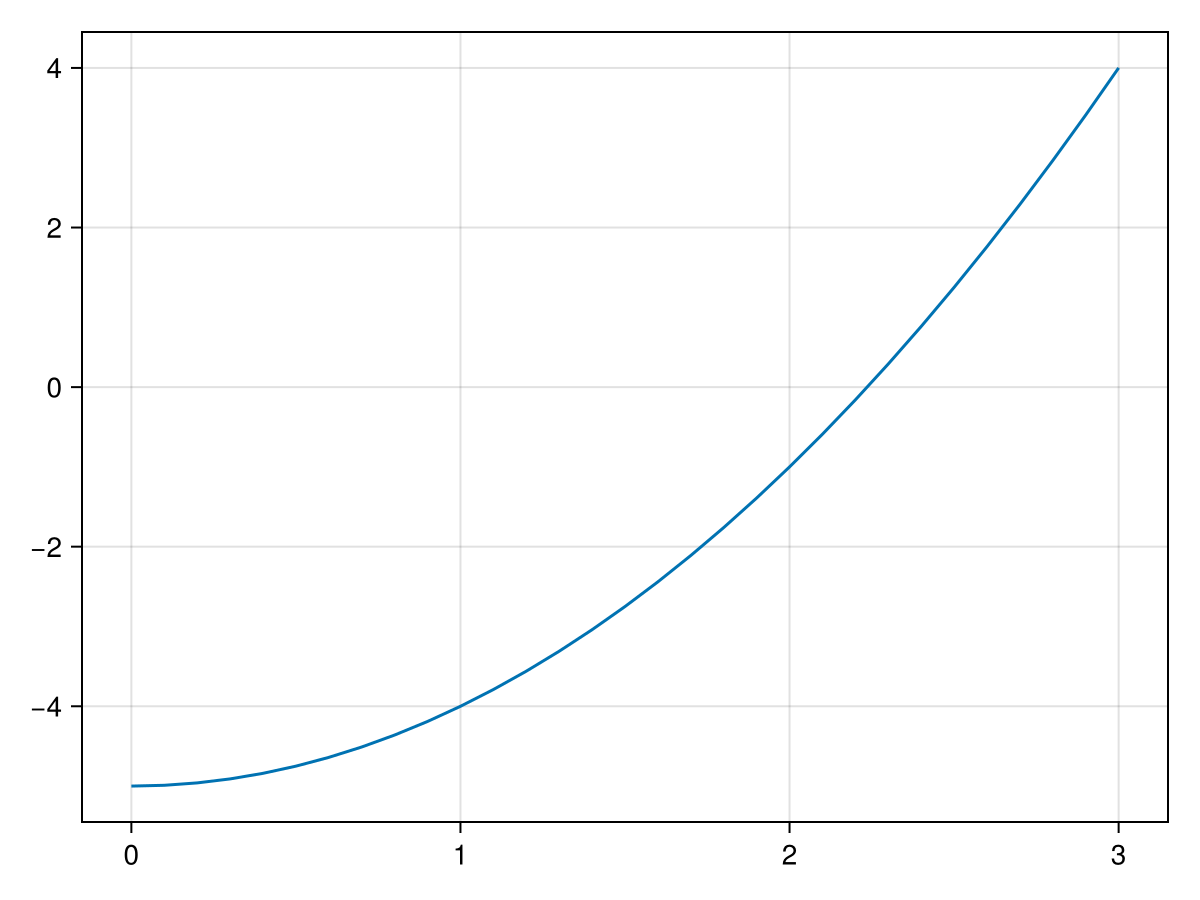

In [50]:
lines(0:0.1:3, x->x.^2-5)

In [51]:
g(x) = x^2-5

g (generic function with 1 method)

In [52]:
g(I"[1,3]")

[-4.0, 4.0]_com_NG

In [53]:
ForwardDiff.derivative(g,I"[1,3]")

[2.0, 6.0]_com_NG

In [54]:
X0 = I"[1,3]"

[1.0, 3.0]_com

In [79]:
X0 = I"[1,3]"
x0 = I"[3]"
x1 = x0-g(x0)/ForwardDiff.derivative(g,x0)

[2.33333, 2.33333]_com_NG

In [80]:
X1 = (x1 -  g(x1)/ForwardDiff.derivative(g,X0)) ⊓ X0

[2.11111, 2.25926]_trv_NG

In [81]:
interval(sqrt(5),sqrt(5)) ⪽ X1

true

In [82]:
x2 = x1-g(x1)/ForwardDiff.derivative(g,x1)

[2.2381, 2.2381]_com_NG

In [83]:
X2 = (x2 -  g(x2)/ForwardDiff.derivative(g,X1)) ⊓ X1

[2.23595, 2.23609]_trv_NG

In [84]:
interval(sqrt(5),sqrt(5)) ⪽ X2

true